# EfficientNetV2 Epoch Plots from JSON

Loads `history_*_efficientnetv2.json` files and creates:
- Per-strategy `loss vs epoch` and `accuracy vs epoch` plots
- Combined comparison plots across all strategies


In [7]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
if (BASE_DIR / 'history_linear_efficientnetv2.json').exists():
    CKPT_DIR = BASE_DIR
elif (BASE_DIR / 'EfficentNetV2' / 'history_linear_efficientnetv2.json').exists():
    CKPT_DIR = BASE_DIR / 'EfficentNetV2'
else:
    raise FileNotFoundError('Could not find EfficientNetV2 history JSON files from current working directory.')

strategies = {
    'linear': 'history_linear_efficientnetv2.json',
    'bn': 'history_bn_efficientnetv2.json',
    'adapter': 'history_adapter_efficientnetv2.json',
    'lora': 'history_lora_efficientnetv2.json',
    'full': 'history_full_efficientnetv2.json',
}

histories = {}
for key, filename in strategies.items():
    path = CKPT_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f'Missing JSON file: {path}')
    with open(path, 'r') as f:
        histories[key] = json.load(f)

print('Loaded JSON files from:', CKPT_DIR)
for key, hist in histories.items():
    print(f"{key:>7}: epochs={len(hist.get('val_acc', []))}, keys={sorted(hist.keys())}")


Loaded JSON files from: /content
 linear: epochs=23, keys=['epoch_time', 'total_time', 'train_loss', 'trainable_params', 'val_acc', 'val_loss']
     bn: epochs=13, keys=['epoch_time', 'total_time', 'train_loss', 'trainable_params', 'val_acc', 'val_loss']
adapter: epochs=6, keys=['epoch_time', 'total_time', 'train_loss', 'trainable_params', 'val_acc', 'val_loss']
   lora: epochs=4, keys=['epoch_time', 'total_time', 'train_loss', 'trainable_params', 'val_acc', 'val_loss']
   full: epochs=5, keys=['epoch_time', 'total_time', 'train_loss', 'trainable_params', 'val_acc', 'val_loss']


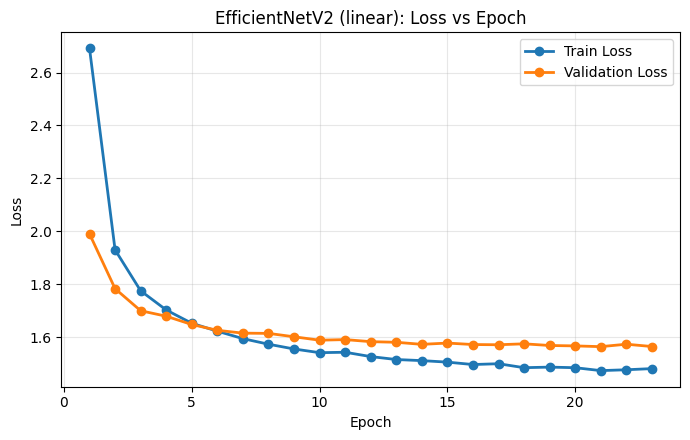

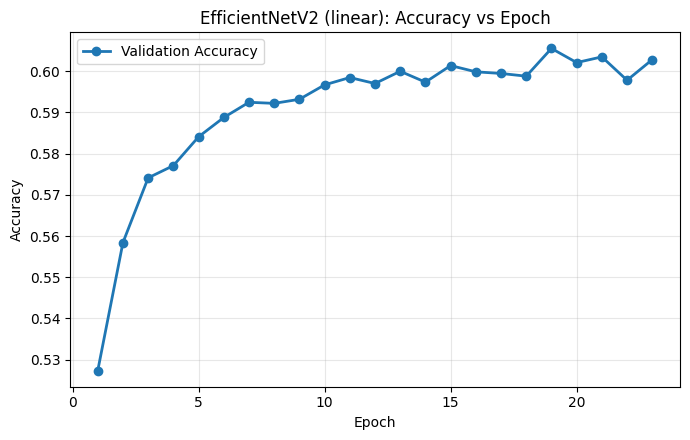

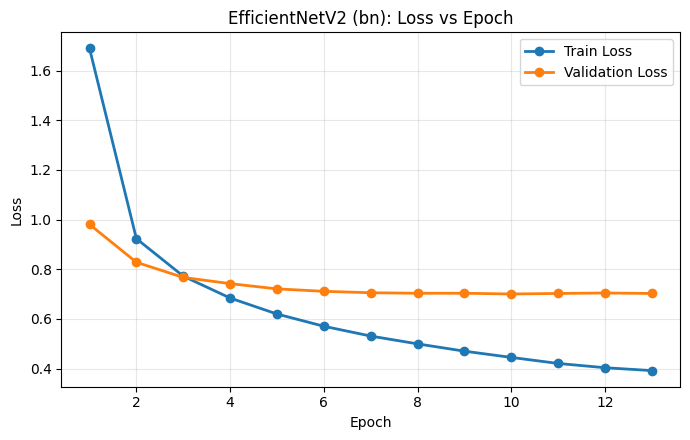

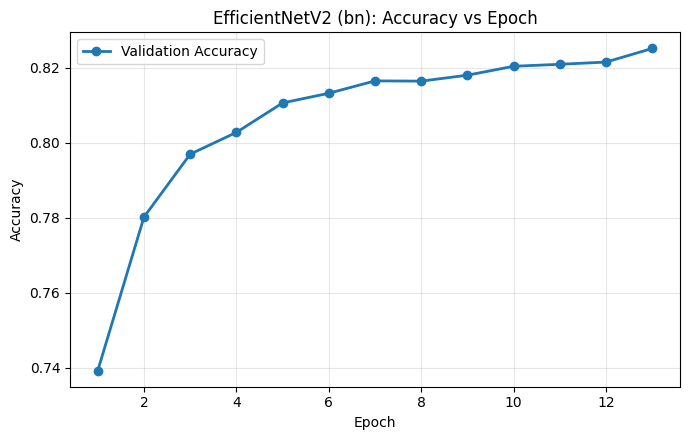

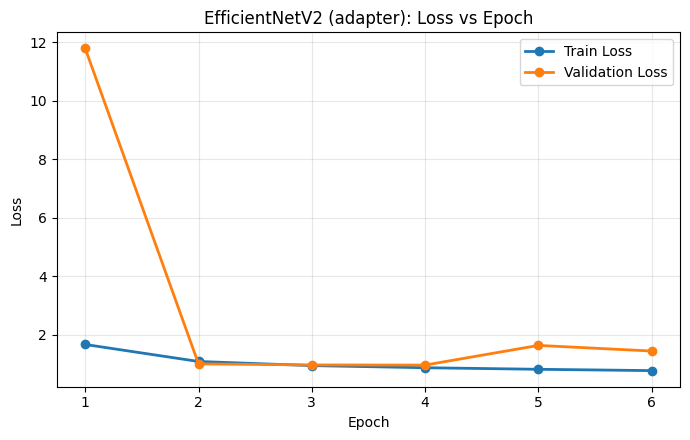

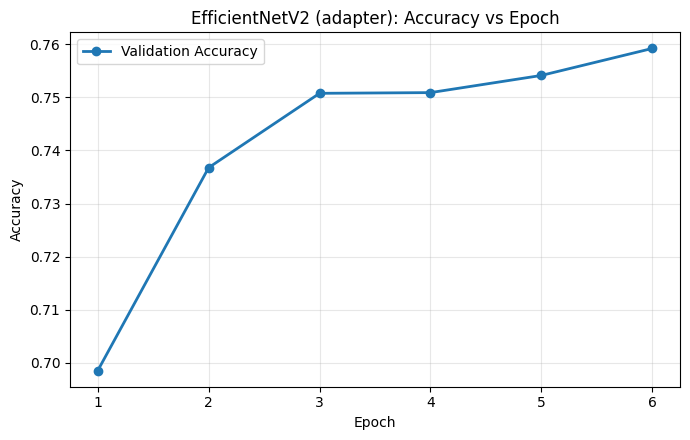

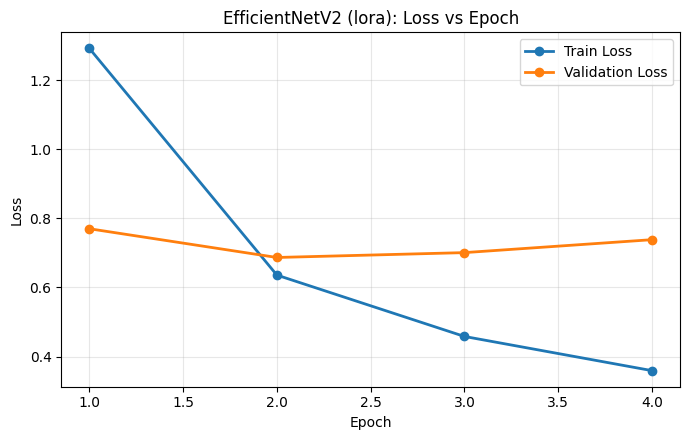

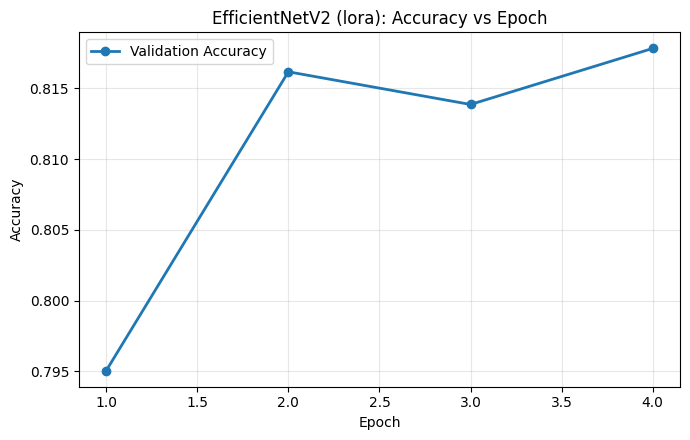

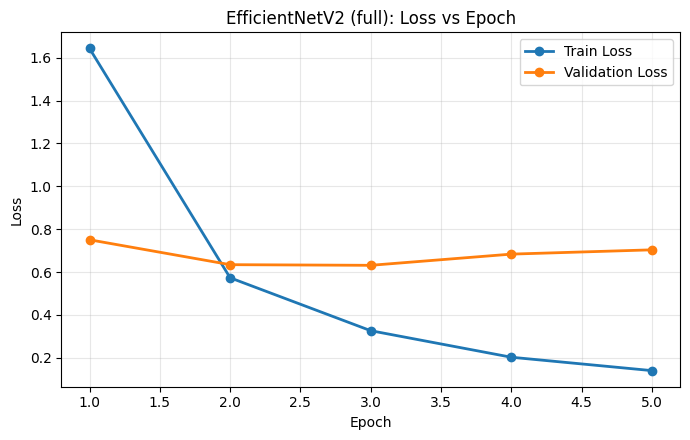

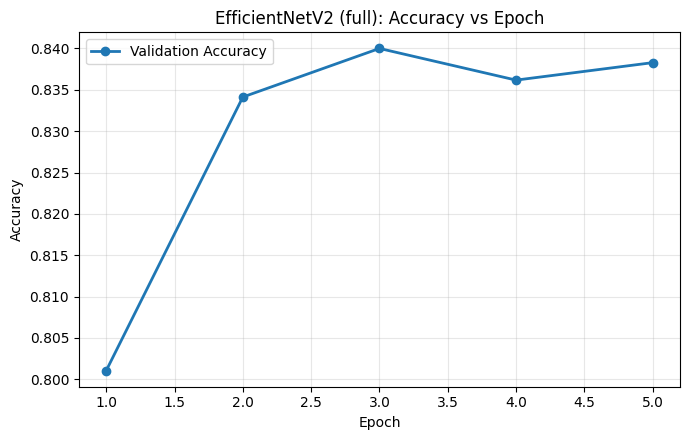

Saved per-strategy plots to: /content


In [8]:
# Per-strategy plots
for key, hist in histories.items():
    epochs_loss = np.arange(1, len(hist.get('train_loss', [])) + 1)
    epochs_acc = np.arange(1, len(hist.get('val_acc', [])) + 1)

    # Loss vs epoch
    plt.figure(figsize=(7, 4.5))
    if len(hist.get('train_loss', [])):
        plt.plot(epochs_loss, hist['train_loss'], marker='o', linewidth=2, label='Train Loss')
    if len(hist.get('val_loss', [])):
        plt.plot(epochs_loss, hist['val_loss'], marker='o', linewidth=2, label='Validation Loss')
    plt.title(f'EfficientNetV2 ({key}): Loss vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(CKPT_DIR / f'loss_curve_{key}_efficientnetv2.png', dpi=220)
    plt.show()

    # Accuracy vs epoch (validation)
    plt.figure(figsize=(7, 4.5))
    if len(hist.get('val_acc', [])):
        plt.plot(epochs_acc, hist['val_acc'], marker='o', linewidth=2, label='Validation Accuracy')
    plt.title(f'EfficientNetV2 ({key}): Accuracy vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(CKPT_DIR / f'accuracy_curve_{key}_efficientnetv2.png', dpi=220)
    plt.show()

print('Saved per-strategy plots to:', CKPT_DIR)


## Variant Failure Analysis

This section follows the same analysis flow as `vit_analysis`:
1. Load EfficientNetV2 strategy checkpoints and datasets.
2. Evaluate performance on clean and transformed variant test sets.
3. Build required trade-off visualizations:
   - performance vs wall-clock training time (bubble size = trainable params)
   - performance vs FLOPs (if `fvcore` is installed)
   - inference speed vs performance (bubble size = trainable params)
4. Use Grad-CAM to compare failure behavior across strategies on the hardest variant.


In [9]:
# Core imports and paths
import gc
import json
import math
import tarfile
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'history_linear_efficientnetv2.json').exists():
    alt = PROJECT_DIR / 'EfficentNetV2'
    if (alt / 'history_linear_efficientnetv2.json').exists():
        PROJECT_DIR = alt

print('PROJECT_DIR:', PROJECT_DIR)

history_files = {
    'linear_probe': PROJECT_DIR / 'history_linear_efficientnetv2.json',
    'batchnorm_tuning': PROJECT_DIR / 'history_bn_efficientnetv2.json',
    'adapter_tuning': PROJECT_DIR / 'history_adapter_efficientnetv2.json',
    'lora_tuning': PROJECT_DIR / 'history_lora_efficientnetv2.json',
    'full_finetune': PROJECT_DIR / 'history_full_efficientnetv2.json',
}

ckpt_files = {
    'linear_probe': PROJECT_DIR / 'best_linear_model_efficientnetv2.pth',
    'batchnorm_tuning': PROJECT_DIR / 'batch_norm_model_efficientnetv2.pth',
    'adapter_tuning': PROJECT_DIR / 'adapter_model_efficientnetv2.pth',
    'lora_tuning': PROJECT_DIR / 'lora_model_efficientnetv2.pth',
    'full_finetune': PROJECT_DIR / 'full_model_efficientnetv2.pth',
}

STRATEGIES = [s for s in ['linear_probe', 'batchnorm_tuning', 'adapter_tuning', 'lora_tuning', 'full_finetune'] if ckpt_files[s].exists()]
print('Strategies:', STRATEGIES)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device:', device)


PROJECT_DIR: /content
Strategies: ['linear_probe', 'batchnorm_tuning', 'adapter_tuning', 'lora_tuning', 'full_finetune']
Device: cuda


In [10]:
# Data/model definitions
weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
transform = weights.transforms()


def is_food101_root(p: Path) -> bool:
    return (p / 'images').is_dir() and (p / 'meta' / 'train.txt').is_file() and (p / 'meta' / 'test.txt').is_file()


def find_food101_root() -> Path:
    candidates = [
        Path('/Users/jordankaseram/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101'),
        PROJECT_DIR / 'food-101' / 'food-101',
        PROJECT_DIR / 'food-101',
        PROJECT_DIR.parent / 'food-101' / 'food-101',
        PROJECT_DIR.parent / 'food-101',
        Path.cwd() / 'food-101' / 'food-101',
        Path.cwd() / 'food-101',
    ]
    for c in candidates:
        if is_food101_root(c):
            return c
    try:
        import kagglehub
        kpath = Path(kagglehub.dataset_download('dansbecker/food-101'))
        for c in [kpath / 'food-101' / 'food-101', kpath / 'food-101', kpath]:
            if is_food101_root(c):
                return c
    except Exception as e:
        print('kagglehub fallback not available:', e)
    raise FileNotFoundError('Could not find Food-101 root.')


class Food101Dataset(Dataset):
    def __init__(self, root, split_file, transform=None, class_to_idx=None):
        self.root = Path(root)
        self.transform = transform
        with open(split_file, 'r', encoding='utf-8') as f:
            self.samples = [x.strip() for x in f if x.strip()]
        if class_to_idx is None:
            classes = sorted({x.split('/')[0] for x in self.samples})
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        else:
            self.class_to_idx = dict(class_to_idx)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        cls = item.split('/')[0]
        img = Image.open(self.root / 'images' / f'{item}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[cls]


class ImageFolderRemapped(Dataset):
    def __init__(self, root, transform, class_to_idx_ref):
        self.base = datasets.ImageFolder(str(root), transform=transform)
        self.index_map = {
            bi: class_to_idx_ref[c]
            for c, bi in self.base.class_to_idx.items()
            if c in class_to_idx_ref
        }

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, y = self.base[idx]
        return img, self.index_map[y]


DATA_ROOT = find_food101_root()
print('DATA_ROOT:', DATA_ROOT)

train_ref = Food101Dataset(DATA_ROOT, DATA_ROOT / 'meta' / 'train.txt', transform=transform)
test_ds = Food101Dataset(DATA_ROOT, DATA_ROOT / 'meta' / 'test.txt', transform=transform, class_to_idx=train_ref.class_to_idx)
test_loader = DataLoader(test_ds, batch_size=64 if device.type == 'cuda' else 16, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))

num_classes = len(train_ref.class_to_idx)
idx_to_class = {v: k for k, v in train_ref.class_to_idx.items()}


def build_model():
    m = efficientnet_v2_s(weights=weights)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m


class ConvAdapter(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.down = nn.Conv2d(channels, hidden, kernel_size=1, bias=False)
        self.up = nn.Conv2d(hidden, channels, kernel_size=1, bias=False)
        self.act = nn.ReLU(inplace=True)
        nn.init.zeros_(self.up.weight)

    def forward(self, x):
        return x + self.up(self.act(self.down(x)))


class BlockWithAdapter(nn.Module):
    def __init__(self, block, channels, reduction=8):
        super().__init__()
        self.block = block
        self.adapter = ConvAdapter(channels, reduction)

    def forward(self, x):
        return self.adapter(self.block(x))


def last_conv_out_channels(module):
    out = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            out = m.out_channels
    return out


def apply_adapter(model):
    for i, block in enumerate(model.features):
        c = last_conv_out_channels(block)
        if c is not None:
            model.features[i] = BlockWithAdapter(block, c, reduction=8)


class LoRAConv2d(nn.Module):
    def __init__(self, conv, rank=16, alpha=16.0):
        super().__init__()
        self.conv = conv
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        for p in self.conv.parameters():
            p.requires_grad = False

        in_feat = (conv.in_channels // conv.groups) * conv.kernel_size[0] * conv.kernel_size[1]
        self.lora_A = nn.Parameter(torch.zeros(conv.out_channels, rank))
        self.lora_B = nn.Parameter(torch.zeros(rank, in_feat))
        nn.init.kaiming_uniform_(self.lora_B, a=math.sqrt(5))
        nn.init.zeros_(self.lora_A)

    def forward(self, x):
        base = self.conv(x)
        dw = (self.lora_A @ self.lora_B).view(
            self.conv.out_channels,
            self.conv.in_channels // self.conv.groups,
            self.conv.kernel_size[0],
            self.conv.kernel_size[1],
        )
        delta = F.conv2d(
            x,
            dw * self.scaling,
            bias=None,
            stride=self.conv.stride,
            padding=self.conv.padding,
            dilation=self.conv.dilation,
            groups=self.conv.groups,
        )
        return base + delta


def inject_lora(module, rank=16, alpha=16.0):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Conv2d) and child.kernel_size == (1, 1):
            setattr(module, name, LoRAConv2d(child, rank=rank, alpha=alpha))
        else:
            inject_lora(child, rank=rank, alpha=alpha)


def apply_lora(model, rank=16, alpha=16.0):
    inject_lora(model.features, rank=rank, alpha=alpha)


def infer_lora_rank_from_state_dict(state_dict):
    for k, v in state_dict.items():
        if k.endswith('lora_A') and hasattr(v, 'shape') and len(v.shape) == 2:
            return int(v.shape[1])
    return 16


def load_strategy_model(strategy):
    model = build_model()

    state = torch.load(ckpt_files[strategy], map_location='cpu')

    if strategy == 'adapter_tuning':
        apply_adapter(model)
    elif strategy == 'lora_tuning':
        rank = infer_lora_rank_from_state_dict(state)
        apply_lora(model, rank=rank, alpha=float(rank))

    model.load_state_dict(state, strict=True)
    return model.to(device).eval()


def mark_trainable_like_training(strategy, model):
    if strategy == 'full_finetune':
        for p in model.parameters():
            p.requires_grad = True
        return

    for p in model.parameters():
        p.requires_grad = False

    # classifier head is trainable in linear/BN/LoRA/adapter settings
    for p in model.classifier.parameters():
        p.requires_grad = True

    if strategy == 'batchnorm_tuning':
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                if m.weight is not None:
                    m.weight.requires_grad = True
                if m.bias is not None:
                    m.bias.requires_grad = True
    elif strategy == 'adapter_tuning':
        for m in model.modules():
            if isinstance(m, ConvAdapter):
                for p in m.parameters():
                    p.requires_grad = True
    elif strategy == 'lora_tuning':
        for m in model.modules():
            if isinstance(m, LoRAConv2d):
                for p in m.parameters():
                    p.requires_grad = True


def count_trainable_params_for_strategy(strategy):
    m = build_model()
    if strategy == 'adapter_tuning':
        apply_adapter(m)
    elif strategy == 'lora_tuning':
        # Match training setup used for LoRA checkpoint generation.
        apply_lora(m, rank=16, alpha=16.0)
    mark_trainable_like_training(strategy, m)
    n = int(sum(p.numel() for p in m.parameters() if p.requires_grad))
    del m
    return n


def sync_device():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps' and hasattr(torch, 'mps') and hasattr(torch.mps, 'synchronize'):
        torch.mps.synchronize()


def measure_inference_ips(model, loader, warmup=5, max_batches=30):
    model.eval()
    with torch.no_grad():
        i = 0
        for imgs, _ in loader:
            _ = model(imgs.to(device))
            i += 1
            if i >= warmup:
                break
        sync_device()

        seen = 0
        t0 = time.time()
        i = 0
        for imgs, _ in loader:
            _ = model(imgs.to(device))
            seen += imgs.size(0)
            i += 1
            if i >= max_batches:
                break
        sync_device()

    return seen / max(time.time() - t0, 1e-9)


DATA_ROOT: /root/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101


In [11]:
# Variant dataset download/discovery
from google.colab import drive
drive.mount('/content/drive')

USE_GOOGLEDRIVE_VARIANTS = False
LOCAL_VARIANT_ZIP = Path('/content/drive/MyDrive/food101_test_variants.zip')  # change if in subfolder
EXTRACT_DIR = Path('/content/food101_transformed_test_variants/extracted')

if not LOCAL_VARIANT_ZIP.exists():
    raise FileNotFoundError(f'Zip not found: {LOCAL_VARIANT_ZIP}')

if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.iterdir()):
    print('Extracting local zip...')
    extract_archive(LOCAL_VARIANT_ZIP, EXTRACT_DIR)
else:
    print('Using existing extracted folder:', EXTRACT_DIR)

variant_sets = discover_variant_sets(EXTRACT_DIR)
if not variant_sets:
    raise RuntimeError('Could not discover variant folders after extraction.')

print('Discovered variant sets:', sorted(variant_sets.keys()))


def maybe_download_variant_archive(output_dir, file_id, archive_name):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    archive_path = output_dir / archive_name

    if archive_path.exists() and archive_path.stat().st_size > 0:
        print('Using existing archive:', archive_path)
        return archive_path

    try:
        import gdown
    except ImportError as exc:
        raise RuntimeError('Install gdown first: pip install gdown') from exc

    print('Downloading transformed test variants from Google Drive...')
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url=url, output=str(archive_path), quiet=False)

    if not archive_path.exists() or archive_path.stat().st_size == 0:
        raise RuntimeError('Download failed: archive not found or empty.')

    return archive_path


def extract_archive(archive_path, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    suffixes = [s.lower() for s in archive_path.suffixes]
    if archive_path.suffix.lower() == '.zip':
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(output_dir)
    elif '.tar' in suffixes or suffixes[-2:] in [['.tar', '.gz'], ['.tar', '.bz2'], ['.tar', '.xz']]:
        with tarfile.open(archive_path, 'r:*') as tf:
            tf.extractall(output_dir)
    else:
        raise ValueError(f'Unsupported archive type: {archive_path}')


def _contains_class_folders(path):
    if not path.is_dir():
        return False

    class_dirs = [d for d in path.iterdir() if d.is_dir()]
    if not class_dirs:
        return False

    exts = {'.jpg', '.jpeg', '.png', '.webp'}
    hits = 0
    for class_dir in class_dirs[:8]:
        for f in class_dir.iterdir():
            if f.is_file() and f.suffix.lower() in exts:
                hits += 1
                break

    return hits >= max(1, min(3, len(class_dirs)))


def discover_variant_sets(root):
    root = Path(root)
    variants = {}

    if not root.exists():
        return variants

    if _contains_class_folders(root):
        variants[root.name] = root
        return variants

    for child in sorted(root.iterdir()):
        if child.is_dir() and _contains_class_folders(child):
            variants[child.name] = child

    if variants:
        return variants

    for child in sorted(root.iterdir()):
        if not child.is_dir():
            continue
        for grandchild in sorted(child.iterdir()):
            if grandchild.is_dir() and _contains_class_folders(grandchild):
                variants[grandchild.name] = grandchild

    return variants


if USE_GOOGLEDRIVE_VARIANTS:
    archive_path = maybe_download_variant_archive(VARIANT_DOWNLOAD_DIR, GOOGLEDRIVE_FILE_ID, VARIANT_ARCHIVE_NAME)
    if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.iterdir()):
        print('Extracting transformed test variants...')
        extract_archive(archive_path, EXTRACT_DIR)
    else:
        print('Using existing extracted folder:', EXTRACT_DIR)

variant_sets = discover_variant_sets(EXTRACT_DIR)
if not variant_sets:
    raise RuntimeError('Could not discover variant folders after extraction.')

print('Discovered variant sets:', sorted(variant_sets.keys()))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using existing extracted folder: /content/food101_transformed_test_variants/extracted
Discovered variant sets: ['blur_little', 'blur_medium', 'clean', 'downsampled', 'masked', 'noise_rotation']
Discovered variant sets: ['blur_little', 'blur_medium', 'clean', 'downsampled', 'masked', 'noise_rotation']


In [12]:
# Variant + clean evaluation and summary table
# Set RUN_SINGLE_STRATEGY to one of:
# 'linear_probe', 'batchnorm_tuning', 'adapter_tuning', 'lora_tuning', 'full_finetune'
# Use None to run all strategies.
RUN_SINGLE_STRATEGY = None

MAX_EVAL_SAMPLES_PER_VARIANT = 2000  # set None for full run
BATCH_SIZE = 64 if device.type == 'cuda' else 16
criterion_eval = nn.CrossEntropyLoss(reduction='sum')

if RUN_SINGLE_STRATEGY is None:
    ACTIVE_STRATEGIES = list(STRATEGIES)
else:
    if RUN_SINGLE_STRATEGY not in STRATEGIES:
        raise ValueError(f'Unknown strategy: {RUN_SINGLE_STRATEGY}. Available: {STRATEGIES}')
    ACTIVE_STRATEGIES = [RUN_SINGLE_STRATEGY]

print('Running strategies:', ACTIVE_STRATEGIES)


def evaluate_loader(model, loader):
    loss_sum = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss_sum += criterion_eval(logits, y).item()
            y_true.extend(y.cpu().tolist())
            y_pred.extend(logits.argmax(1).cpu().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_pred == y_true).mean()) if len(y_true) else 0.0
    avg_loss = float(loss_sum / max(len(y_true), 1))
    return {'acc': acc, 'loss': avg_loss, 'y_true': y_true, 'y_pred': y_pred}


strategy_trainable_params = {s: count_trainable_params_for_strategy(s) for s in ACTIVE_STRATEGIES}

rows = []
pred_store = {}
true_store = {}
variant_datasets = {}
failed_strategies = {}

for variant_name, variant_dir in sorted(variant_sets.items()):
    ds_full = ImageFolderRemapped(variant_dir, transform=transform, class_to_idx_ref=train_ref.class_to_idx)

    if MAX_EVAL_SAMPLES_PER_VARIANT is not None:
        ds = Subset(ds_full, list(range(min(MAX_EVAL_SAMPLES_PER_VARIANT, len(ds_full)))))
    else:
        ds = ds_full

    variant_datasets[variant_name] = ds
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))

    for strategy in ACTIVE_STRATEGIES:
        try:
            model = load_strategy_model(strategy)
            metrics = evaluate_loader(model, loader)
        except Exception as e:
            failed_strategies[strategy] = str(e)
            print(f'[WARN] {strategy} failed on variant {variant_name}: {e}')
            continue

        pred_store[(variant_name, strategy)] = metrics['y_pred']
        true_store[variant_name] = metrics['y_true']

        rows.append({
            'variant': variant_name,
            'strategy': strategy,
            'accuracy': metrics['acc'],
            'loss': metrics['loss'],
            'num_samples': int(len(metrics['y_true'])),
        })

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        if torch.backends.mps.is_available() and hasattr(torch, 'mps'):
            torch.mps.empty_cache()

# clean test metrics
for strategy in ACTIVE_STRATEGIES:
    try:
        model = load_strategy_model(strategy)
        clean_metrics = evaluate_loader(model, test_loader)
    except Exception as e:
        failed_strategies[strategy] = str(e)
        print(f'[WARN] {strategy} failed on clean test: {e}')
        continue

    rows.append({
        'variant': 'clean',
        'strategy': strategy,
        'accuracy': clean_metrics['acc'],
        'loss': clean_metrics['loss'],
        'num_samples': int(len(clean_metrics['y_true'])),
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available() and hasattr(torch, 'mps'):
        torch.mps.empty_cache()

if not rows:
    raise RuntimeError('No successful evaluations. Check checkpoint/model compatibility.')

results_long = pd.DataFrame(rows)

# Guard against duplicate (strategy, variant) rows before pivot
if results_long.duplicated(subset=['strategy', 'variant']).any():
    dup_n = int(results_long.duplicated(subset=['strategy', 'variant']).sum())
    print(f'[WARN] Found {dup_n} duplicate strategy/variant rows; aggregating with mean accuracy/loss.')
    results_long = (
        results_long
        .groupby(['strategy', 'variant'], as_index=False)
        .agg({'accuracy': 'mean', 'loss': 'mean', 'num_samples': 'sum'})
    )

results_wide = results_long.pivot(index='strategy', columns='variant', values='accuracy').sort_index()

variant_only = results_long[results_long['variant'] != 'clean']
variant_mean_acc = variant_only.groupby('variant')['accuracy'].mean().sort_values()
hardest_variant = variant_mean_acc.index[0]

y_true_hard = true_store[hardest_variant]
error_counts = np.zeros(len(y_true_hard), dtype=int)
for s in ACTIVE_STRATEGIES:
    if (hardest_variant, s) in pred_store:
        error_counts += (pred_store[(hardest_variant, s)] != y_true_hard).astype(int)

chosen_failure_idx = int(error_counts.argmax())
n_wrong_at_failure_idx = int(error_counts[chosen_failure_idx])

print(results_wide)
print()
print('Variant mean accuracy (ascending):')
print(variant_mean_acc)
print('Hardest variant:', hardest_variant)
print('Chosen failure idx:', chosen_failure_idx, '| #wrong strategies at this idx:', n_wrong_at_failure_idx)
if failed_strategies:
    print()
    print('Failed strategies:')
    for k, v in failed_strategies.items():
        print('-', k, '->', v[:200])

# Build summary rows for trade-off plots
history_map = {}
for s, hp in history_files.items():
    if hp.exists():
        with open(hp, 'r') as f:
            history_map[s] = json.load(f)
    else:
        history_map[s] = {}

clean_rows = results_long[results_long['variant'] == 'clean']
summary_rows = []
for s in ACTIVE_STRATEGIES:
    if s in failed_strategies:
        continue

    clean_match = clean_rows[clean_rows['strategy'] == s]
    clean_test_acc = float(clean_match['accuracy'].iloc[0]) if len(clean_match) else np.nan
    clean_test_loss = float(clean_match['loss'].iloc[0]) if len(clean_match) else np.nan

    h = history_map.get(s, {})
    summary_rows.append({
        'strategy': s,
        'clean_test_acc': clean_test_acc,
        'clean_test_loss': clean_test_loss,
        'trainable_params': int(h.get('trainable_params')) if h.get('trainable_params') is not None else strategy_trainable_params.get(s, np.nan),
        'train_seconds': float(h.get('total_time')) if h.get('total_time') is not None else np.nan,
        'best_val_acc': max(h['val_acc']) if h.get('val_acc') else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)

# inference speed
ips_map = {}
for s in summary_df['strategy'].tolist():
    model = load_strategy_model(s)
    ips_map[s] = measure_inference_ips(model, test_loader)
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available() and hasattr(torch, 'mps'):
        torch.mps.empty_cache()

summary_df['inference_ips'] = summary_df['strategy'].map(ips_map)

# optional FLOPs
try:
    from fvcore.nn import FlopCountAnalysis
    dummy = torch.randn(1, 3, 384, 384).to(device)
    flops_map = {}
    for s in summary_df['strategy'].tolist():
        model = load_strategy_model(s).eval()
        flops_map[s] = float(FlopCountAnalysis(model, dummy).total() / 1e9)
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        if torch.backends.mps.is_available() and hasattr(torch, 'mps'):
            torch.mps.empty_cache()
    summary_df['flops_g'] = summary_df['strategy'].map(flops_map)
except Exception as e:
    print('FLOPs not computed (install fvcore to enable):', e)

suffix = 'all' if RUN_SINGLE_STRATEGY is None else RUN_SINGLE_STRATEGY
results_long_path = PROJECT_DIR / f'efficientnetv2_variant_results_long_{suffix}.csv'
results_wide_path = PROJECT_DIR / f'efficientnetv2_variant_results_wide_{suffix}.csv'
summary_path = PROJECT_DIR / f'efficientnetv2_strategy_summary_{suffix}.csv'

results_long.to_csv(results_long_path, index=False)
results_wide.to_csv(results_wide_path)
summary_df.to_csv(summary_path, index=False)

print()
print('Saved:')
print('-', results_long_path)
print('-', results_wide_path)
print('-', summary_path)
print()
print('Summary:')
print(summary_df)


Running strategies: ['linear_probe', 'batchnorm_tuning', 'adapter_tuning', 'lora_tuning', 'full_finetune']
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 147MB/s]


[WARN] Found 5 duplicate strategy/variant rows; aggregating with mean accuracy/loss.
variant           blur_little  blur_medium     clean  downsampled  masked  \
strategy                                                                    
adapter_tuning         0.6985       0.4430  0.773240       0.1790  0.7445   
batchnorm_tuning       0.7920       0.6095  0.849017       0.2905  0.8370   
full_finetune          0.7990       0.6260  0.865282       0.3545  0.8485   
linear_probe           0.4375       0.2035  0.631230       0.1025  0.5920   
lora_tuning            0.7450       0.5385  0.833540       0.3010  0.7915   

variant           noise_rotation  
strategy                          
adapter_tuning            0.7255  
batchnorm_tuning          0.8190  
full_finetune             0.8220  
linear_probe              0.5810  
lora_tuning               0.7860  

Variant mean accuracy (ascending):
variant
downsampled       0.2455
blur_medium       0.4841
blur_little       0.6944
noise_rotat

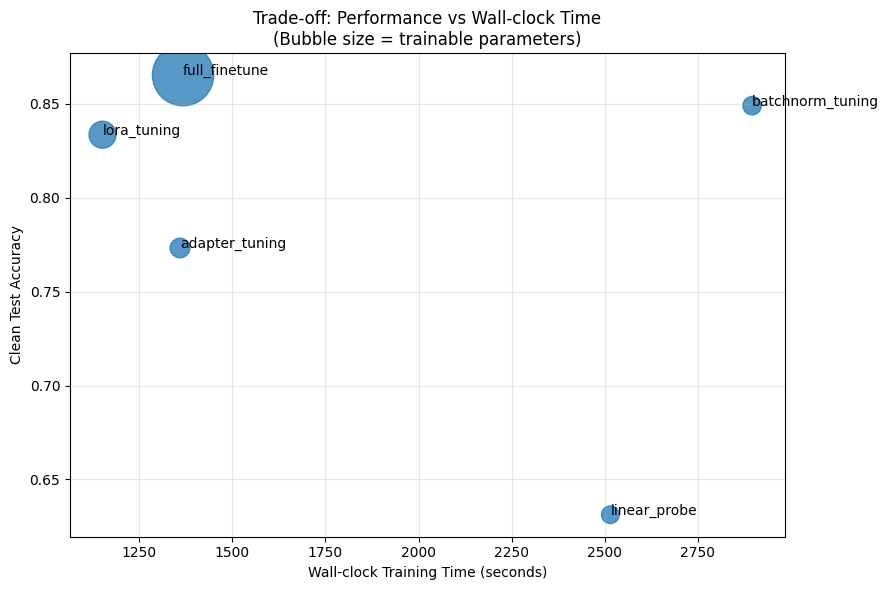

Saved: /content/tradeoff_perf_vs_time.png


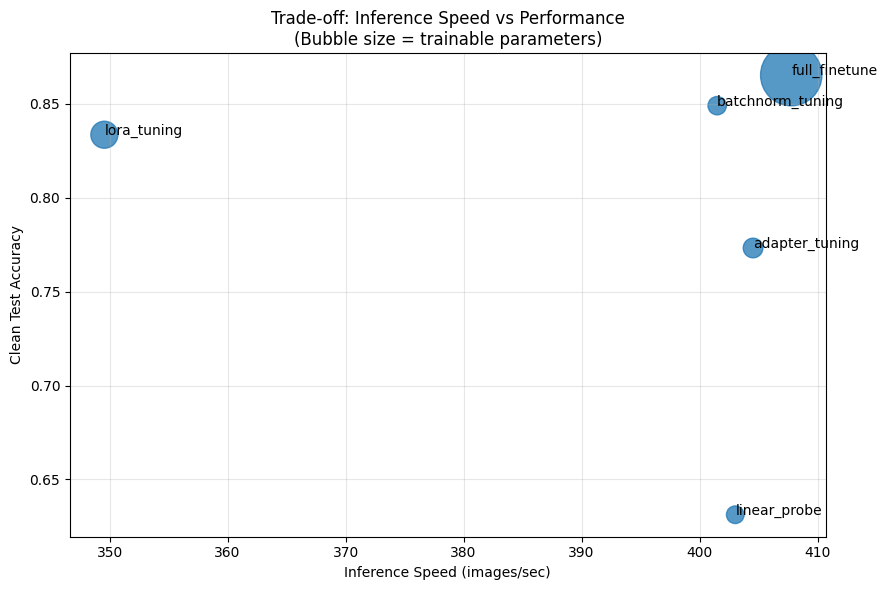

Saved: /content/tradeoff_inference_vs_perf.png


In [13]:
# Required trade-off visualizations
if 'summary_df' not in globals():
    summary_df = pd.read_csv(PROJECT_DIR / 'efficientnetv2_strategy_summary.csv')


def bubble_plot(df, x_col, y_col, x_label, y_label, title, out_name, x_log=False):
    size = (df['trainable_params'] / df['trainable_params'].max()) * 1800 + 150

    plt.figure(figsize=(9, 6))
    plt.scatter(df[x_col], df[y_col], s=size, alpha=0.75)

    for _, r in df.iterrows():
        plt.annotate(r['strategy'], (r[x_col], r[y_col]))

    if x_log:
        plt.xscale('log')

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title + '\n(Bubble size = trainable parameters)')
    plt.grid(alpha=0.3)
    plt.tight_layout()

    out_path = PROJECT_DIR / out_name
    plt.savefig(out_path, dpi=220)
    plt.show()
    print('Saved:', out_path)


bubble_plot(
    summary_df,
    x_col='train_seconds',
    y_col='clean_test_acc',
    x_label='Wall-clock Training Time (seconds)',
    y_label='Clean Test Accuracy',
    title='Trade-off: Performance vs Wall-clock Time',
    out_name='tradeoff_perf_vs_time.png',
)

bubble_plot(
    summary_df,
    x_col='inference_ips',
    y_col='clean_test_acc',
    x_label='Inference Speed (images/sec)',
    y_label='Clean Test Accuracy',
    title='Trade-off: Inference Speed vs Performance',
    out_name='tradeoff_inference_vs_perf.png',
)

if 'flops_g' in summary_df.columns and summary_df['flops_g'].notna().any():
    bubble_plot(
        summary_df,
        x_col='flops_g',
        y_col='clean_test_acc',
        x_label='Model FLOPs (GFLOPs)',
        y_label='Clean Test Accuracy',
        title='Trade-off: Performance vs FLOPs',
        out_name='tradeoff_perf_vs_flops.png',
    )


In [14]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=4d4df867c1365378d91bd0fc8af7351e18a0fe98ae83ebf90272cbb49680d102
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


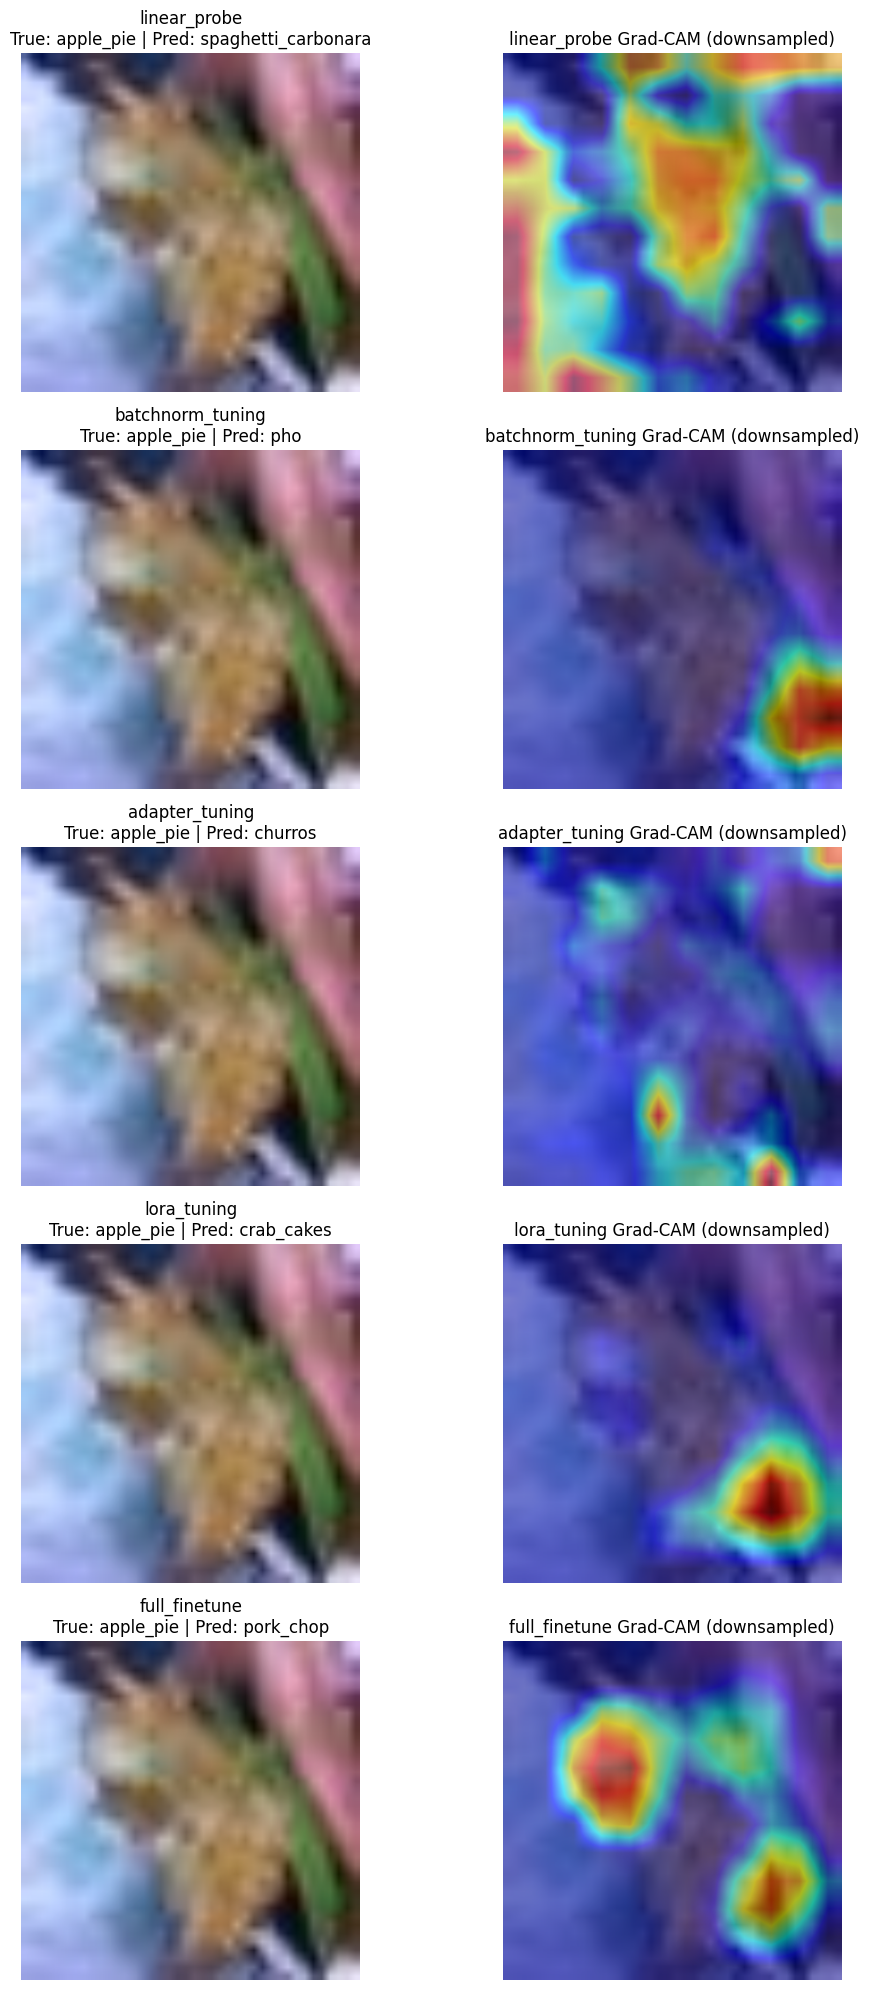

Saved: /content/gradcam_failure_comparison.png


In [15]:
# Grad-CAM on selected failure sample from hardest variant
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception as exc:
    raise RuntimeError('Install grad-cam first: pip install grad-cam') from exc

if 'hardest_variant' not in globals() or 'chosen_failure_idx' not in globals():
    raise ValueError('Run the evaluation cell first to set hardest_variant/chosen_failure_idx.')

if 'ACTIVE_STRATEGIES' not in globals() or not ACTIVE_STRATEGIES:
    raise ValueError('No evaluated strategies found. Run the evaluation cell first.')

ds = variant_datasets[hardest_variant]
img_t, y_true = ds[chosen_failure_idx]
x = img_t.unsqueeze(0).to(device)

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
img_np = img_t.permute(1, 2, 0).cpu().numpy()
img_np = np.clip(img_np * std + mean, 0, 1)

fig, axes = plt.subplots(len(ACTIVE_STRATEGIES), 2, figsize=(11, 4 * len(ACTIVE_STRATEGIES)))
if len(ACTIVE_STRATEGIES) == 1:
    axes = np.array([axes])

for i, strategy in enumerate(ACTIVE_STRATEGIES):
    model = load_strategy_model(strategy)

    with torch.no_grad():
        pred = int(model(x).argmax(1).item())

    target_layers = [model.features[-1]]
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(
            input_tensor=x,
            targets=[ClassifierOutputTarget(pred)],
            eigen_smooth=True,
        )[0]

    overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"{strategy}\nTrue: {idx_to_class[int(y_true)]} | Pred: {idx_to_class[pred]}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"{strategy} Grad-CAM ({hardest_variant})")
    axes[i, 1].axis('off')

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available() and hasattr(torch, 'mps'):
        torch.mps.empty_cache()

plt.tight_layout()
out_path = PROJECT_DIR / 'gradcam_failure_comparison.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


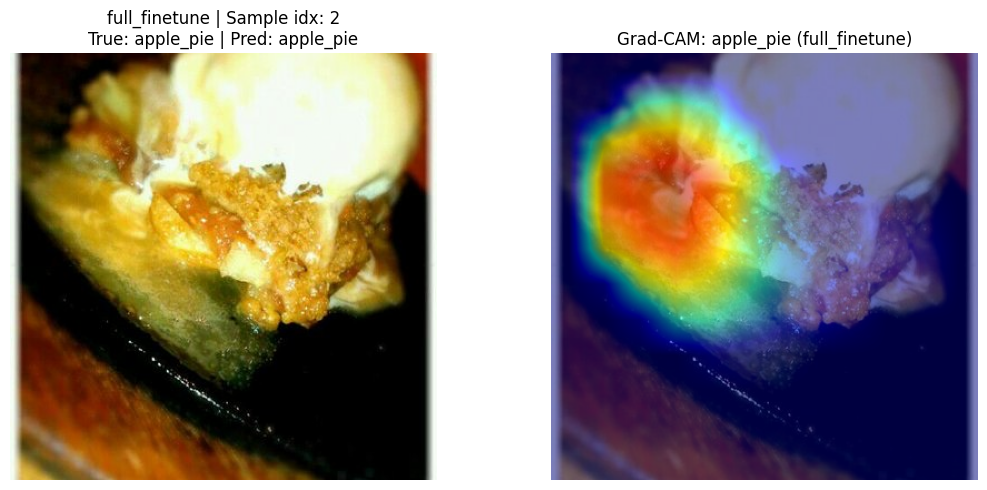

Saved: /content/gradcam_apple_pie_full_finetune.png


In [16]:
# Grad-CAM for apple_pie using full_finetune (clean test set)
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception as exc:
    raise RuntimeError('Install grad-cam first: pip install grad-cam') from exc

if 'test_ds' not in globals() or 'idx_to_class' not in globals():
    raise ValueError('Run the data/model setup cells first (through test_ds creation).')

if 'load_strategy_model' not in globals():
    raise ValueError('Run the model-definition cell first so load_strategy_model exists.')

class_to_idx = {v: k for k, v in idx_to_class.items()}
if 'apple_pie' not in class_to_idx:
    raise ValueError("Class 'apple_pie' not found in class mapping.")

apple_idx = class_to_idx['apple_pie']
model = load_strategy_model('full_finetune')
model.eval()

# Prefer a correctly predicted apple_pie sample; fallback to first apple_pie sample.
chosen_idx = None
chosen_pred = None
x = None
y_true = None

with torch.no_grad():
    for i in range(len(test_ds)):
        img_t, y = test_ds[i]
        if int(y) != int(apple_idx):
            continue

        logits = model(img_t.unsqueeze(0).to(device))
        pred = int(logits.argmax(1).item())

        if chosen_idx is None:
            chosen_idx = i
            chosen_pred = pred
            x = img_t.unsqueeze(0).to(device)
            y_true = int(y)

        if pred == apple_idx:
            chosen_idx = i
            chosen_pred = pred
            x = img_t.unsqueeze(0).to(device)
            y_true = int(y)
            break

if chosen_idx is None:
    raise RuntimeError("Could not find any 'apple_pie' sample in test set.")

img_t = x.squeeze(0).detach().cpu()
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
img_np = img_t.permute(1, 2, 0).numpy()
img_np = np.clip(img_np * std + mean, 0, 1)

# Use predicted class as Grad-CAM target (typically apple_pie for chosen sample).
target_layers = [model.features[-1]]
with GradCAM(model=model, target_layers=target_layers) as cam:
    grayscale_cam = cam(
        input_tensor=x,
        targets=[ClassifierOutputTarget(chosen_pred)],
        eigen_smooth=True,
    )[0]

overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img_np)
axes[0].set_title(
    f"full_finetune | Sample idx: {chosen_idx}\n"
    f"True: {idx_to_class[y_true]} | Pred: {idx_to_class[chosen_pred]}"
)
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title('Grad-CAM: apple_pie (full_finetune)')
axes[1].axis('off')

plt.tight_layout()
out_path = PROJECT_DIR / 'gradcam_apple_pie_full_finetune.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', out_path)

# cleanup
if torch.cuda.is_available():
    torch.cuda.empty_cache()
if torch.backends.mps.is_available() and hasattr(torch, 'mps'):
    torch.mps.empty_cache()



Variant path: /content/food101_transformed_test_variants/extracted/downsampled/apple_pie/1011328.jpg
Clean path  : /root/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101/images/apple_pie/1011328.jpg
Class       : apple_pie


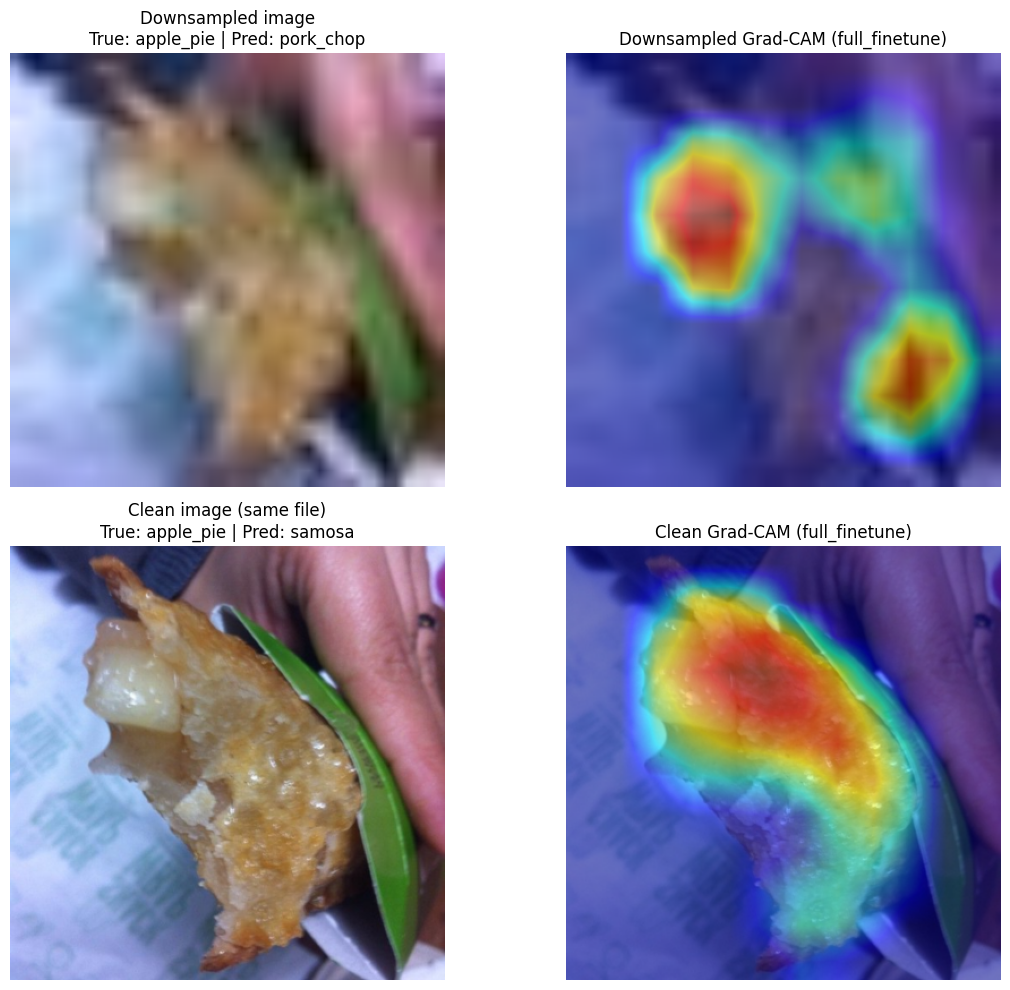

Saved: /content/gradcam_compare_apple_pie_full_finetune_downsampled_vs_clean.png


In [17]:
# Grad-CAM comparison: same sample in downsampled variant vs clean (full_finetune)
# This uses the same failure sample selected in cell 8: hardest_variant + chosen_failure_idx.
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception as exc:
    raise RuntimeError('Install grad-cam first: pip install grad-cam') from exc

if 'hardest_variant' not in globals() or 'chosen_failure_idx' not in globals():
    raise ValueError('Run the evaluation cell first so hardest_variant/chosen_failure_idx are set.')

if 'variant_datasets' not in globals():
    raise ValueError('Run the evaluation cell first so variant_datasets exists.')

if 'load_strategy_model' not in globals() or 'idx_to_class' not in globals():
    raise ValueError('Run model/data setup cells first (load_strategy_model, idx_to_class).')

if hardest_variant != 'downsampled':
    print(f"Note: hardest_variant is '{hardest_variant}', not 'downsampled'. Using hardest_variant anyway.")

# Resolve the exact sample path from variant_datasets[hardest_variant][chosen_failure_idx].
var_ds = variant_datasets[hardest_variant]
if isinstance(var_ds, Subset):
    base_ds = var_ds.dataset
    base_idx = var_ds.indices[chosen_failure_idx]
else:
    base_ds = var_ds
    base_idx = chosen_failure_idx

# base_ds is ImageFolderRemapped, which wraps torchvision ImageFolder in .base
variant_path, _orig_label = base_ds.base.samples[base_idx]
variant_path = Path(variant_path)
class_name = variant_path.parent.name
file_name = variant_path.name

# Build clean counterpart path from Food-101 canonical location
clean_img_path = DATA_ROOT / 'images' / class_name / file_name
if not clean_img_path.exists():
    msg = (
        'Clean counterpart not found for variant sample.\n'
        + f'  variant: {variant_path}\n'
        + f'  expected clean: {clean_img_path}'
    )
    raise FileNotFoundError(msg)

# Variant tensor (already transformed)
var_img_t, var_y = var_ds[chosen_failure_idx]
x_var = var_img_t.unsqueeze(0).to(device)

# Clean tensor (same transform pipeline)
clean_pil = Image.open(clean_img_path).convert('RGB')
clean_img_t = transform(clean_pil)
x_clean = clean_img_t.unsqueeze(0).to(device)

model = load_strategy_model('full_finetune')
model.eval()

with torch.no_grad():
    pred_var = int(model(x_var).argmax(1).item())
    pred_clean = int(model(x_clean).argmax(1).item())

# De-normalize for visualization
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

var_np = var_img_t.permute(1, 2, 0).cpu().numpy()
var_np = np.clip(var_np * std + mean, 0, 1)

clean_np = clean_img_t.permute(1, 2, 0).cpu().numpy()
clean_np = np.clip(clean_np * std + mean, 0, 1)

# Grad-CAMs (target predicted class on each view)
target_layers = [model.features[-1]]
with GradCAM(model=model, target_layers=target_layers) as cam:
    cam_var = cam(
        input_tensor=x_var,
        targets=[ClassifierOutputTarget(pred_var)],
        eigen_smooth=True,
    )[0]

    cam_clean = cam(
        input_tensor=x_clean,
        targets=[ClassifierOutputTarget(pred_clean)],
        eigen_smooth=True,
    )[0]

overlay_var = show_cam_on_image(var_np, cam_var, use_rgb=True)
overlay_clean = show_cam_on_image(clean_np, cam_clean, use_rgb=True)

true_cls = idx_to_class[int(var_y)]
print('Variant path:', variant_path)
print('Clean path  :', clean_img_path)
print('Class       :', true_cls)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(var_np)
axes[0, 0].set_title(f"Downsampled image\nTrue: {true_cls} | Pred: {idx_to_class[pred_var]}")
axes[0, 0].axis('off')

axes[0, 1].imshow(overlay_var)
axes[0, 1].set_title(f"Downsampled Grad-CAM (full_finetune)")
axes[0, 1].axis('off')

axes[1, 0].imshow(clean_np)
axes[1, 0].set_title(f"Clean image (same file)\nTrue: {true_cls} | Pred: {idx_to_class[pred_clean]}")
axes[1, 0].axis('off')

axes[1, 1].imshow(overlay_clean)
axes[1, 1].set_title(f"Clean Grad-CAM (full_finetune)")
axes[1, 1].axis('off')

plt.tight_layout()
out_path = PROJECT_DIR / f'gradcam_compare_{true_cls}_full_finetune_downsampled_vs_clean.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', out_path)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
if torch.backends.mps.is_available() and hasattr(torch, 'mps'):
    torch.mps.empty_cache()
